# Evaluation

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.lines as mlines
import logging
from scipy.stats import ttest_ind

from WassersteinTSNE import GaussianDistribution, plotGaussian
from sklearn.decomposition import PCA

import sys
sys.path.insert(0, '../src')

from utils.logger import logger
import utils.visualization as vis
import utils.preprocession as prep
from IPython.display import display

logging.captureWarnings(True)
logger = logging.getLogger('py.warnings')
logger.addHandler(logging.NullHandler())
logger.setLevel(logging.ERROR)

save_figures = []
save_figures.append('../reports/PLOS Paper/figures/eps')


## Data Generation

In [25]:
candidates = pd.read_csv('../data/candidates.csv', index_col=0)
candidate_reactions = pd.read_csv('../data/candidates_reactions.csv', index_col=0)
voters_reactions = pd.read_csv('../data/voters_reactions.csv', index_col=0)
questions = pd.read_csv('../data/questions.csv', index_col=0)
gpt_data = pd.read_csv('../results/gpt/2023/gpt4_results.csv', index_col=[0,1])
gpt_voters = pd.read_csv('../data/gpt_voters.csv', index_col=0)
true_means = pd.read_csv('../data/party_means.csv', index_col=0)
true_stds = pd.read_csv('../data/party_stds.csv', index_col=0)
true_means.columns.name = 'party'
true_means.index = true_means.index.astype(str)
true_stds.columns.name = 'party'
true_stds.index = true_means.index.astype(str)

### GPT Temperature

In [3]:
var = gpt_data.groupby(level=[0,1]).std().mean(axis=1).groupby(level=1).mean()
mean = gpt_data.groupby(level=[0,1]).mean().sub(true_means.T, level='party').abs().mean(axis=1).groupby(level=1).mean()
std = gpt_data.groupby(level=[0,1]).mean().sub(true_means.T, level='party').abs().std(axis=1).groupby(level=1).mean()
nan = gpt_data.isna().sum(axis=1).groupby(level=1).sum()
temperature = pd.concat([mean, var, nan], axis=1)
temperature.columns=[ 'Mean Distance', 'Response Variance', 'Missing Values']
print(temperature.mean().values)
print(np.round(temperature['Missing Values'].values/75/9*10,2))
print(28.6/9*10/75)
temperature


[ 0.14302854  0.10534505 28.6       ]
[0.   0.01 0.01 0.3  1.79]
0.4237037037037037


,Mean Distance,Response Variance,Missing Values
temperature,,,
1.00,0.145823,0.080852,0
1.25,0.144420,0.095608,1
1.50,0.142608,0.109044,1
1.75,0.143458,0.116885,20
2.00,0.138834,0.124336,121


In [4]:
# Define the file path
file_path = '../reports/PLOS Paper/tables/Temperature.tex'
caption = 'GPT-4 results for different temperatures (noise parameter) and three metrics. The mean distance is computed between the  average GPT-4 estimate to the respective party mean. The response variance corresponds to the standard deviation across multiple trials for the same party and temperature. The missing values depict the number of trials in which the GPT-4 answer could not be transferred to an integer between 0 and 100.'

table = temperature.copy()
# Format all float columns to have exactly three decimal places
for column in table.select_dtypes(include=['float']):
    table[column] = table[column].map(lambda x: f"{x:.3f}")
table.index = table.index.map(lambda x: f"{x:.2f}")
table.index.name = 'Temperature'
table = table.reset_index()

table_str = table.to_latex(index=False ,caption=caption, label='tab:temperature', escape=False,)
table_str = table_str.replace('{lllr}', '{cccc}')
table_str = table_str.replace('Temperature', '\\makecell{Temperature}')
table_str = table_str.replace('Mean Distance', '\\makecell{Mean\\\\Distance}')
table_str = table_str.replace('Response Variance', '\\makecell{Response\\\\Variance}')
table_str = table_str.replace('Missing Values', '\\makecell{Missing\\\\Values}')
### Convert DataFrame to LaTeX table and save it to a file
# with open(file_path, 'w') as f:
#     f.write(table_str)

### GPT Accuracy

In [94]:
candidate_reactions.index=candidates.list
candidate_reactions

,32214,32215,32216,32217,32218,32219,32220,32221,32222,32223,...,32279,32280,32281,32282,32283,32284,32285,32286,32287,32288
list,,,,,,,,,,,,,,,,,,,,,
FDP,1.00,0.25,1.00,1.00,0.00,0.25,1.00,0.00,0.75,0.00,...,0.17,0.17,0.25,1.00,0.00,0.75,0.25,0.50,0.50,0.25
GLP,0.25,0.75,0.75,0.00,0.75,1.00,0.00,1.00,0.00,1.00,...,0.33,0.83,0.50,0.75,0.75,0.50,0.25,0.75,0.75,0.00
EVP,1.00,1.00,1.00,0.00,0.00,0.75,0.00,0.25,0.00,0.25,...,0.33,0.67,0.50,0.75,0.50,0.75,0.50,0.50,0.50,0.50
Übrige,0.00,1.00,1.00,0.00,1.00,1.00,0.25,0.75,0.00,0.00,...,0.00,1.00,1.00,1.00,0.50,1.00,0.00,0.50,0.00,1.00
SP,0.00,1.00,0.25,0.00,1.00,1.00,0.25,0.25,0.00,0.00,...,0.00,1.00,0.75,1.00,0.25,1.00,0.00,0.50,0.25,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SVP,0.75,0.00,0.75,0.75,0.00,0.00,0.00,0.00,0.75,0.75,...,0.83,0.00,0.00,0.25,0.75,0.25,0.75,0.75,0.75,0.00
Mitte,0.75,0.75,1.00,0.75,0.75,0.00,0.00,1.00,0.75,0.75,...,0.33,0.33,0.50,0.75,0.25,0.50,0.50,0.50,0.50,0.75
Mitte,1.00,0.75,0.75,1.00,1.00,0.25,0.00,0.00,0.25,0.00,...,0.17,1.00,0.75,0.75,0.25,0.25,0.50,0.50,0.75,0.50


In [89]:
gpt_data.droplevel(1)

,32214,32215,32216,32217,32218,32219,32220,32221,32222,32223,...,32279,32280,32281,32282,32283,32284,32285,32286,32287,32288
party,,,,,,,,,,,,,,,,,,,,,
EDU,0.25,0.60,0.00,0.00,0.30,0.25,0.00,0.00,0.40,1.00,...,0.60,0.30,0.50,0.50,0.50,0.50,0.50,0.80,0.70,0.3
EDU,0.00,0.50,0.00,0.00,0.30,0.30,0.00,0.00,0.00,1.00,...,0.50,0.20,0.50,0.50,0.50,0.30,0.85,0.70,0.70,0.3
EDU,0.00,0.50,0.50,0.00,0.00,0.30,0.35,0.00,0.50,1.00,...,0.85,0.20,0.30,0.50,0.50,0.50,0.50,0.80,0.75,0.3
EDU,0.00,0.70,0.00,0.00,0.35,0.30,0.00,0.00,0.30,1.00,...,0.60,0.35,0.50,0.40,0.50,0.50,0.60,1.00,0.50,0.3
EDU,0.50,0.50,0.00,0.00,0.40,0.30,0.00,0.00,0.20,0.80,...,0.60,0.30,0.30,0.40,0.50,0.70,0.70,0.80,0.50,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Übrige,0.52,0.34,0.99,0.00,0.75,0.20,0.57,0.90,0.20,0.85,...,0.20,0.72,0.45,1.00,0.26,0.65,0.50,0.70,0.50,0.5
Übrige,0.60,0.50,0.53,0.50,0.80,0.44,0.50,0.10,0.70,0.85,...,0.30,0.70,0.65,0.80,0.50,0.50,0.65,0.70,0.50,0.5
Übrige,0.40,0.60,1.00,0.35,0.60,0.60,0.69,0.85,0.50,0.70,...,0.20,0.50,0.78,0.68,1.00,0.50,0.48,0.50,0.37,0.5


In [90]:
true_means

party,EDU,EVP,FDP,GLP,Grüne,Mitte,SP,SVP,Übrige
32214,0.522222,0.465054,0.979839,0.781046,0.185268,0.503401,0.022222,0.558962,0.278409
32215,0.400000,0.857527,0.108871,0.645425,0.917411,0.675170,0.987037,0.110849,0.615057
32216,0.716667,0.943548,0.673387,0.522876,0.859375,0.933673,0.681481,0.497642,0.784091
32217,0.316667,0.588710,0.899194,0.754902,0.069196,0.693878,0.038889,0.669811,0.264205
32218,0.277778,0.801075,0.197581,0.848039,0.968750,0.744898,0.979630,0.073113,0.569602
...,...,...,...,...,...,...,...,...,...
32284,0.505556,0.717742,0.544355,0.674837,0.919643,0.639456,0.922222,0.408019,0.599432
32285,0.594444,0.325269,0.572581,0.245098,0.064732,0.481293,0.138889,0.686321,0.325284
32286,0.638889,0.543011,0.633065,0.511438,0.406250,0.556122,0.405556,0.719340,0.438920
32287,0.661111,0.459677,0.689516,0.439542,0.165179,0.627551,0.148148,0.794811,0.427557


In [95]:
def compute_differences(row):
    ground_truth = true_means.loc[:,row.name]
    return (row - ground_truth).abs().mean()

gpt_distribution = gpt_data.droplevel(1).apply(compute_differences, axis=1)
can_distribution = candidate_reactions.loc[candidate_reactions.index != 'Übrige'].apply(compute_differences, axis=1)

In [96]:
gpt_distribution

party
EDU       0.197745
EDU       0.195790
EDU       0.172957
EDU       0.193576
EDU       0.199156
            ...   
Übrige    0.212776
Übrige    0.223484
Übrige    0.215013
Übrige    0.182287
Übrige    0.214500
Length: 450, dtype: float64

In [97]:
can_distribution

list
FDP      0.231273
GLP      0.382757
EVP      0.287987
SP       0.099331
Mitte    0.271665
           ...   
SVP      0.145621
Mitte    0.259275
Mitte    0.217827
Grüne    0.107158
SP       0.094152
Length: 853, dtype: float64

In [99]:
t_stat, p_value = ttest_ind(gpt_distribution, can_distribution, equal_var=False, alternative='less')
p_value

3.340285568452106e-10

In [100]:
# Combine the two distributions into a dictionary of results
results = []

# Get the unique groups (parties/lists) that appear in both indices
unique_groups = set(gpt_distribution.index).intersection(set(can_distribution.index))
# unique_groups.remove('Übrige')

# Perform Welch's t-test for each unique group
for group in unique_groups:
    gpt_group = gpt_distribution[gpt_distribution.index == group]
    can_group = can_distribution[can_distribution.index == group]

    # Perform Welch's t-test
    t_stat, p_value = ttest_ind(gpt_group, can_group, equal_var=False, alternative='less')

    # Append the results
    results.append({
        "Party": group,
        "T-statistic": t_stat,
        "P-value": p_value
    })

# Convert results to a DataFrame
results_df = pd.DataFrame(results).set_index('Party')
results_df

,T-statistic,P-value
Party,,
Mitte,-8.915639,3.386544e-16
EVP,-8.314435,1.540268e-13
GLP,-4.666153,2.957714e-06
SP,6.319840,1.000000e+00
EDU,-6.447014,1.595739e-08
Grüne,-5.838972,1.993063e-08
FDP,0.627604,7.338107e-01
SVP,-9.396310,1.229383e-16


In [87]:
results_df['GPT-4 Distance'] = gpt_distribution.groupby(level=0).mean()
results_df['GPT-4 Std.'] = gpt_distribution.groupby(level=0).std()
results_df['Candidate Distance'] = can_distribution.groupby(level=0).mean()
results_df['Candidate Std.'] = can_distribution.groupby(level=0).std()
# mean_stds  = true_stds.mean().loc[true_stds.columns != 'Übrige'].mean()
# print('Avergae STD:', mean_stds, 'Candidates Distance:', mean_stds*np.sqrt(2/np.pi), 'GPT-4 Distance:', (true_means - gpt_means).abs().mean().mean())
# results_df.sort_values(by='GPT-4 Distance').plot.bar(rot=0, xlabel='', figsize=(vis.columnwidth, 0.5*vis.columnwidth))
# vis.savefig(plt.gcf(), 'GPT_Mean_Distance', save_figures)
results_df["P-value"] =  pd.to_numeric(results_df['P-value'], errors='coerce')
results_df["P-value"] = results_df['P-value'].map(lambda x: f"{x:.2e}{'*' if x <0.05 else ''}")
cols = [c for c in results_df.columns if c not in ['P-value', 'T-statistic']]
cols.append('P-value')
results_df = results_df[cols]
print(results_df.mean(axis=0,numeric_only=True))
results_df.sort_values(by='Party')

GPT-4 Distance        0.165273
GPT-4 Std.            0.011588
Candidate Distance    0.191260
Candidate Std.        0.050150
dtype: float64


,GPT-4 Distance,GPT-4 Std.,Candidate Distance,Candidate Std.,P-value
Party,,,,,
EDU,0.197019,0.014367,0.237467,0.039819,1.60e-08*
EVP,0.183900,0.011794,0.232233,0.053703,1.54e-13*
FDP,0.195323,0.010351,0.191278,0.049424,7.34e-01
GLP,0.159652,0.011015,0.181728,0.055257,2.96e-06*
Grüne,0.112386,0.010649,0.142805,0.052781,1.99e-08*
Mitte,0.193416,0.011192,0.239198,0.059227,3.39e-16*
SP,0.136365,0.010529,0.112308,0.040704,1.00e+00
SVP,0.144125,0.012804,0.193067,0.050282,1.23e-16*


In [83]:
# Define the file path
file_path = '../reports/PLOS Paper/tables/PartyMeans.tex'
caption = "GPT-4 results for different parties. The distance is computed between the GPT-4 estimates (resp. candidates) and the corresponding party mean. The mean and standard deviation of those distances is averaged across all questions. The p-value corresponds to the Welch's t-test with null hypothesis that GPT-estimates and candidates' distances to the party mean are the same."

table = results_df.copy()
# Format all float columns to have exactly three decimal places
for column in table.select_dtypes(include=['float']):
    table[column] = table[column].map(lambda x: f"{x:.3f}")
table.index.name = "Party"
table = table.reset_index()

table_str = table.to_latex(index=False ,caption=caption, label='tab:party_means')
table_str = table_str.replace('{llllll}', '{cccccc}')
table_str = table_str.replace('GPT-4 Distance', '\\makecell{GPT-4\\\\Distance}')
table_str = table_str.replace('Candidate Distance', '\\makecell{Candidate\\\\Distance}')
table_str = table_str.replace('GPT-4 Std.', '\\makecell{GPT-4\\\\Std.}')
table_str = table_str.replace('Candidate Std.', '\\makecell{Candidate\\\\Std.}')
# Convert DataFrame to LaTeX table and save it to a file
with open(file_path, 'w') as f:
    f.write(table_str)

#### GPT Means

In [4]:
questions.index = questions.index.astype(str)
gpt_means = gpt_data.groupby(level=0).mean().T
gpt_means


party,EDU,EVP,FDP,GLP,Grüne,Mitte,SP,SVP,Übrige
32214,0.209400,0.274400,0.760208,0.698600,0.1390,0.545000,0.129000,0.768750,0.482400
32215,0.482800,0.803200,0.352000,0.672653,0.9040,0.755800,0.970000,0.241000,0.554000
32216,0.189796,0.440408,0.620000,0.504600,0.7246,0.494800,0.780204,0.239000,0.569796
32217,0.018000,0.162400,0.760400,0.676200,0.0560,0.534400,0.009000,0.267000,0.305000
32218,0.256531,0.883400,0.424000,0.865000,1.0000,0.794000,0.998000,0.215600,0.711000
...,...,...,...,...,...,...,...,...,...
32284,0.466600,0.767400,0.498000,0.757000,0.9510,0.743878,0.891000,0.297400,0.594400
32285,0.549400,0.334800,0.573000,0.309000,0.1400,0.481020,0.219600,0.796939,0.507755
32286,0.770204,0.581200,0.578600,0.509000,0.3444,0.582000,0.458400,0.843000,0.555000
32287,0.655000,0.337000,0.528000,0.319600,0.1760,0.441000,0.239000,0.815400,0.480400


In [69]:
diff = (true_means - gpt_means).abs()/(true_stds+.1)
max_val = diff['SVP'].max().max()
max_idx = diff.eq(max_val).stack()[lambda x: x].index.tolist()
print("Maximum value:", max_val)
print("Indices of maximum value:", max_idx)
print(questions.loc[max_idx[0][0], 'question_EN'])
min_val = diff['Grüne'].min().min()
min_idx = diff.eq(min_val).stack()[lambda x: x].index.tolist()
print("Minimum value:", min_val)
print("Indices of minimum value:", min_idx)
print(questions.loc[min_idx[0][0], 'question_EN'])

Maximum value: 1.3528318258332448
Indices of maximum value: [('32253', 'SVP')]
Should direct payments only be granted to farmers with proof of ecological performance?
Minimum value: 0.004281056304196474
Indices of minimum value: [('32238', 'Grüne')]
Would you support the introduction of a national inheritance tax on all inheritances over one million Swiss francs?


In [70]:
qmax = diff.sum(axis=1).idxmax()
questions.loc[qmax, 'question_EN']

'Should the Federal Council be allowed to authorize other states to re-export Swiss weapons in cases of a war of aggression in violation of international law (e.g., the attack on Ukraine)?'

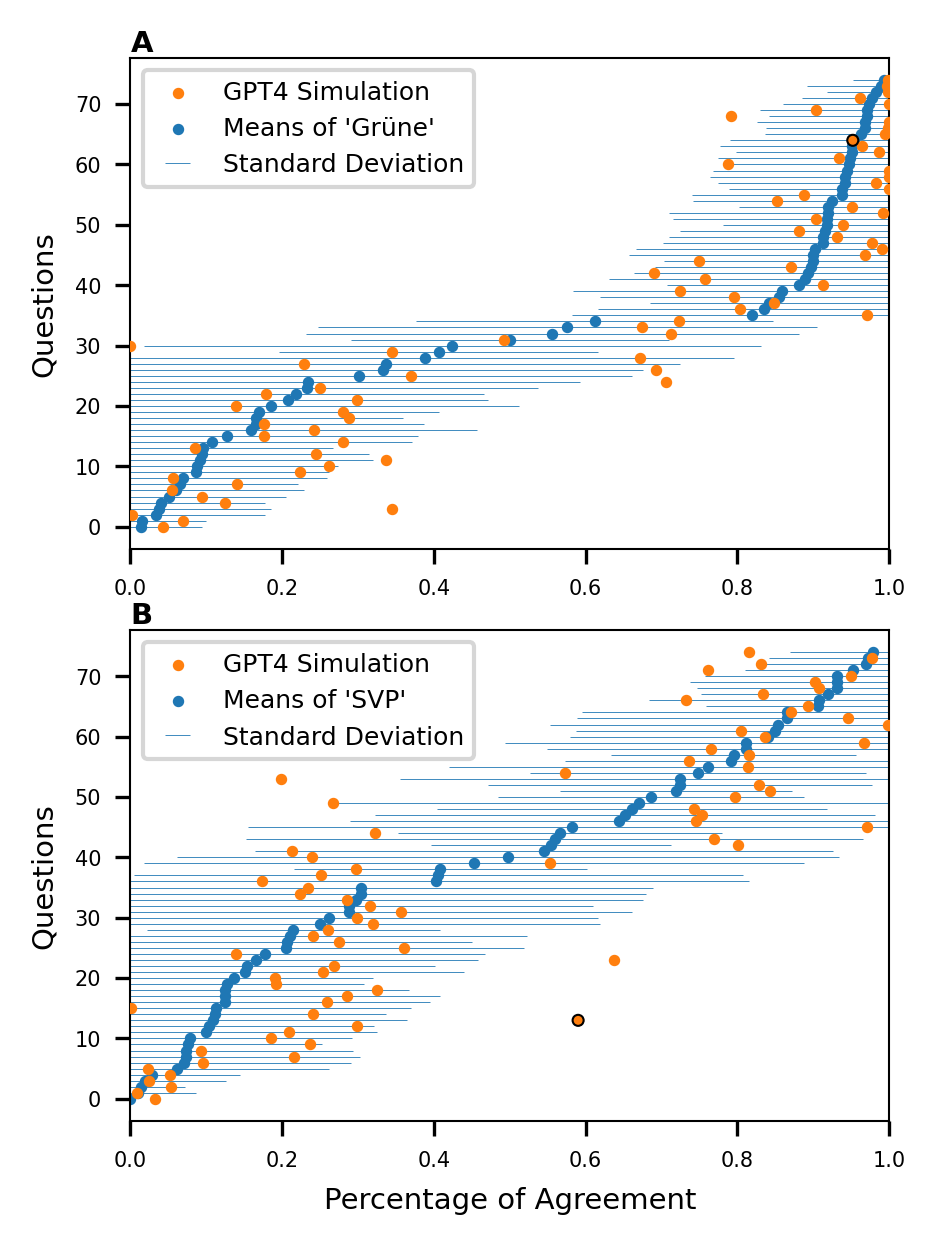

In [71]:
parties = ('Grüne', 'SVP')

fig, axes = plt.subplots(2, 1, figsize=(vis.columnwidth, 1.3*vis.columnwidth))

for party, ax, idx in zip(parties, axes, [min_idx, max_idx]):
    # The x positions for the plot
    idx = idx[0][0]
    y_positions = range(len(true_means.loc[:,party]))

    means = true_means.loc[:,party].sort_values()
    stds = true_stds.loc[means.index,party]
    estimates = gpt_means.loc[means.index,party]

    # Plotting the estimates as scatter
    ax.scatter(estimates[idx], means.index.get_loc(idx), s=7, lw=.5, facecolor='None', edgecolors='black', zorder=4)
    ax.scatter(estimates, y_positions, s=3, color='C1', label='GPT4 Simulation', zorder=3)

    # Plotting the means with std as horizontal error bars
    ax.scatter(means, y_positions, s=3, label=f"Means of '{party}'", color='C0')
    ax.errorbar(means, y_positions, xerr=stds, elinewidth=0.2, fmt='None', label='Standard Deviation', color='C0')

    # Adding labels and title
    ax.set(xlabel='Percentage of Agreement',
            ylabel='Questions',
            # title=f'Mean, STD, and Estimates: {party}',
            xlim=(0,1)
    )
    # plt.yticks(x_positions)  # Set x-ticks to match the positions
    # Adding legend to distinguish between the two types of plots
    ax.legend()

fig.text(-0,1, 'A', va='bottom', ha='left', weight='bold', transform=axes[0].transAxes)
fig.text(-0,1, 'B', va='bottom', ha='left', weight='bold', transform=axes[1].transAxes)
axes[0].set_xlabel('')
plt.subplots_adjust(wspace=0)
fig.tight_layout()

vis.savefig(fig, f'GPT_Comparision_{parties[0]}_{parties[1]}', save_figures)


### Statistical Model

In [26]:
import pickle 
with open('../results/xplore/xplore.pickle', 'rb') as file:
    xplore = pickle.load(file)
xplore.items

,beta1,beta2,alpha
32214,1.722496,3.534239,0.289448
32215,-3.804774,-1.613627,-0.546010
32216,-0.465581,-0.648187,-1.088553
32217,1.937489,4.241500,0.266554
32218,-4.369288,-0.307331,-0.418529
...,...,...,...
32284,-1.791845,-0.445538,-0.605289
32285,1.777255,0.348206,0.381176
32286,0.535111,0.444661,-0.179872
32287,1.890283,0.771417,-0.108474


Figure size in inches: [506.295  172.1403]
Aspect ratio of the figure: 0.34
Do you support an increase in the retirement age (e.g., to 67)?


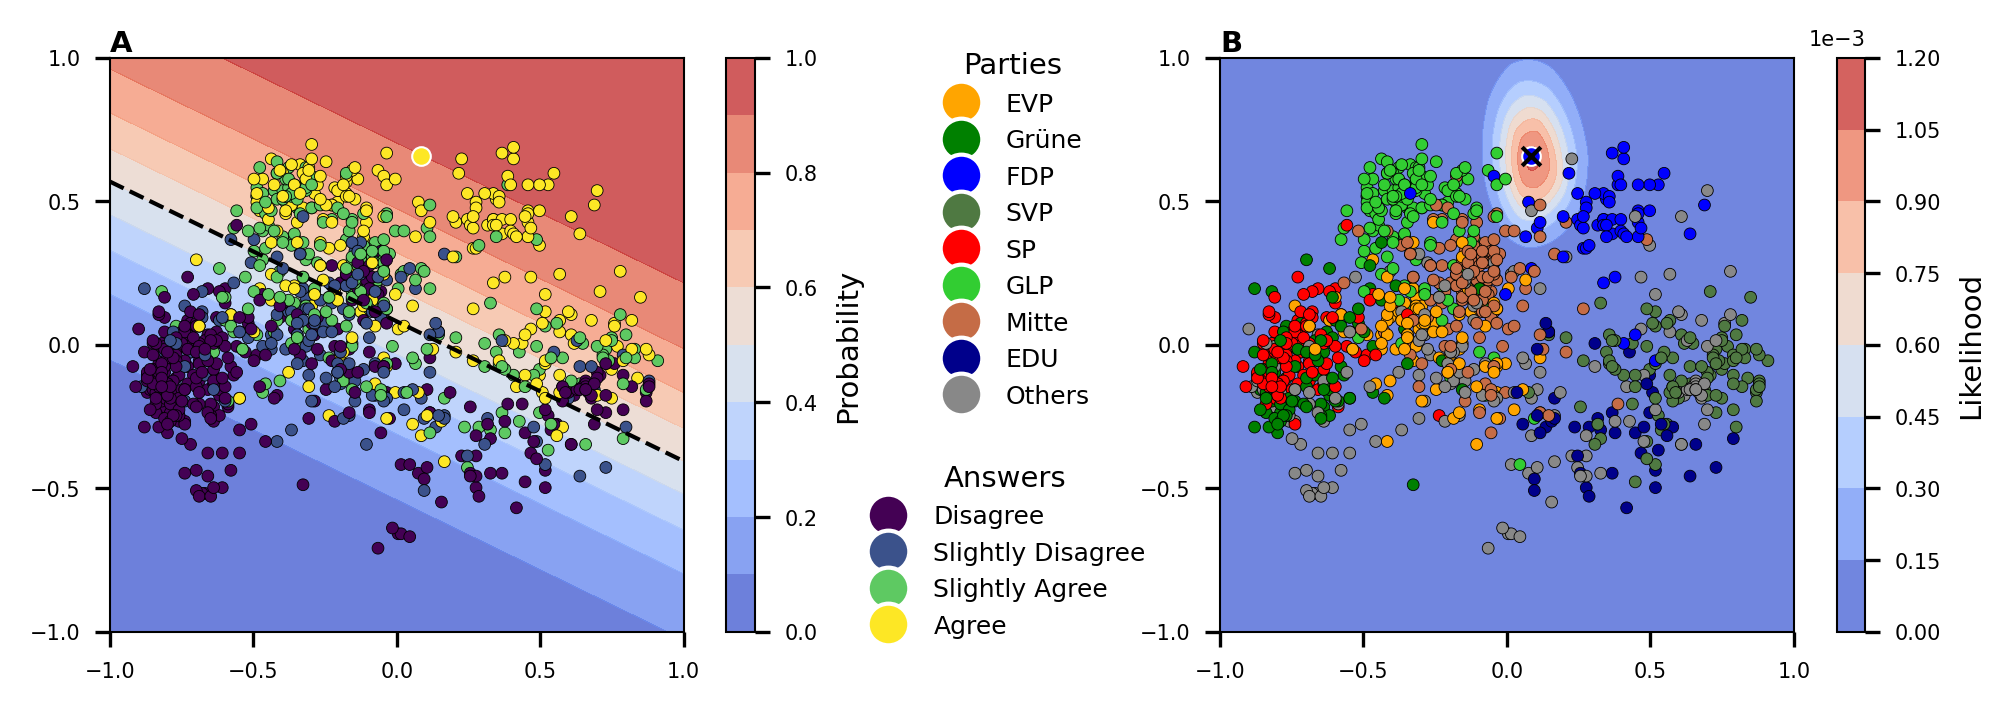

In [27]:
n = xplore.fit_reactions.index[0]
q = '32214'
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(vis.textwidth,.85*.4*vis.textwidth))

train_colors = xplore.fit_users.map(candidates.color.to_dict())
vis.plotEmbedding(xplore.embedding, n=n, c=train_colors, s=8,
                    ax=ax2, highlight={'color':train_colors.loc[n], 's':20})

user = xplore.fit_reactions.loc[n]
# user.loc[:] = np.NaN
answers = user.loc[~user.isna()]
vis.plotObjective(xplore.posterior, answers, d=0, r=xplore.r, area=xplore.area, ax=ax2)

x, y = xplore.embed(answers)
ax2.scatter(x, y, marker='x', color='black', s=20, label='Optimized Coordinates', zorder=5)
# _ = ax1.set_title(f'MSE Loss Function for User {n}')

rgba = vis.colormap(user.astype(float).loc[str(q)])
vis.plotEmbedding(xplore.embedding, n=n, highlight={'color':rgba, 's':20},
                c=xplore.fit_reactions.loc[:,str(q)], ax=ax1, s=8)
vis.plotFeature(xplore.predict, q, d=0, r=xplore.r, area=xplore.area, ax=ax1)
# _ = ax2.set_title(f'Probabilities for Feature {q}')

# Access the colormap
cmap = plt.cm.viridis
# Specify the values to extract colors for
values = [0.0, 0.25, 0.75, 1.0]
# Extract colors for these values
sentiment_colors = [cmap(val) for val in values]
# Map these colors to the sentiments
sentiments = ['Disagree', 'Slightly Disagree', 'Slightly Agree', 'Agree']
sentiment_color_map = dict(zip(sentiments, sentiment_colors))

# Party colors
legend_elements_1 = [Line2D([0], [0], marker='o', color='w', label=key if key != 'Übrige' else 'Others', markersize=10, markerfacecolor=val) for key, val in vis.party_colors.items() if key in candidates.list.unique()]
# Sentiment colors
legend_elements_2 = [Line2D([0], [0], marker='o', color='w', label=key, markersize=10, markerfacecolor=val) for key, val in sentiment_color_map.items()]

# Creating the legend with two columns
ax1.legend(handles=legend_elements_1, loc='upper left', bbox_to_anchor=(1.4, 1.05), title='Parties', ncol=1, frameon=False)
ax2.legend(handles=legend_elements_2, loc='lower right', bbox_to_anchor=(-.09,-.05), title='Answers', ncol=1, frameon=False)

ticks = [-1,-.5, 0, .5, 1]
ax1.set_xticks(ticks)
ax2.set_xticks(ticks)
ax1.set_yticks(ticks)
ax2.set_yticks(ticks)

fig.text(-0,1, 'A', va='bottom', ha='left', weight='bold', transform=ax1.transAxes)
fig.text(-0,1, 'B', va='bottom', ha='left', weight='bold', transform=ax2.transAxes)

fig.tight_layout()
plt.subplots_adjust(wspace=.3)
vis.savefig(fig, 'XPLORE_Candidates_32214', save_figures)


# Print the size of the figure
print("Figure size in inches:", fig.get_size_inches()/vis.inches_pt)
print("Aspect ratio of the figure:", fig.get_figheight()/fig.get_figwidth())
print(questions.loc[int(q), 'question_EN'])

### PCA GPT

In [28]:
gpt_data = pd.read_csv('../data/coldstart.csv', index_col=0)
gpt_means = gpt_data.groupby(level=0).mean().T
gpt_stds = gpt_data.groupby(level=0).std().T
gpt_means.head()

party,EDU,EVP,FDP,GLP,Grüne,Mitte,SP,SVP
32214,0.209400,0.274400,0.760208,0.698600,0.1390,0.5450,0.129000,0.76875
32215,0.482800,0.803200,0.352000,0.672653,0.9040,0.7558,0.970000,0.24100
32216,0.189796,0.440408,0.620000,0.504600,0.7246,0.4948,0.780204,0.23900
32217,0.018000,0.162400,0.760400,0.676200,0.0560,0.5344,0.009000,0.26700
32218,0.256531,0.883400,0.424000,0.865000,1.0000,0.7940,0.998000,0.21560


In [29]:
vertices = pd.read_csv('../data/gpt_extreme_points.csv', index_col=0)

pca = PCA(n_components=2)
Xc = pca.fit_transform(candidate_reactions)
Xv = pca.transform(voters_reactions)
Xe = pca.transform(vertices)
Xq = pca.transform(gpt_voters)
Xg = pca.transform(gpt_data.fillna(.5))
Xm = pca.transform(gpt_means.T.fillna(.5))

T = pd.DataFrame(Xe, index = vertices.index, columns=['X','Y'])
M = pd.DataFrame(Xm, index = gpt_means.columns, columns=['X','Y'])
P = pd.DataFrame(Xg, index = gpt_data.index, columns=['X','Y'])
Q = pd.DataFrame(Xq, index = gpt_voters.index, columns=['X','Y'])
E = pd.DataFrame(Xc, index = candidates['list'], columns=['X','Y'])
V = pd.DataFrame(Xv, columns=['X','Y'])
E.loc[:,'Y'] = -E.loc[:,'Y'] 
P.loc[:,'Y'] = -P.loc[:,'Y'] 
M.loc[:,'Y'] = -M.loc[:,'Y'] 
V.loc[:,'Y'] = -V.loc[:,'Y'] 
Q.loc[:,'Y'] = -Q.loc[:,'Y'] 
T.loc[:,'Y'] = -T.loc[:,'Y'] 

Figure size in inches: [506.295 202.518]
Aspect ratio of the figure: 0.4


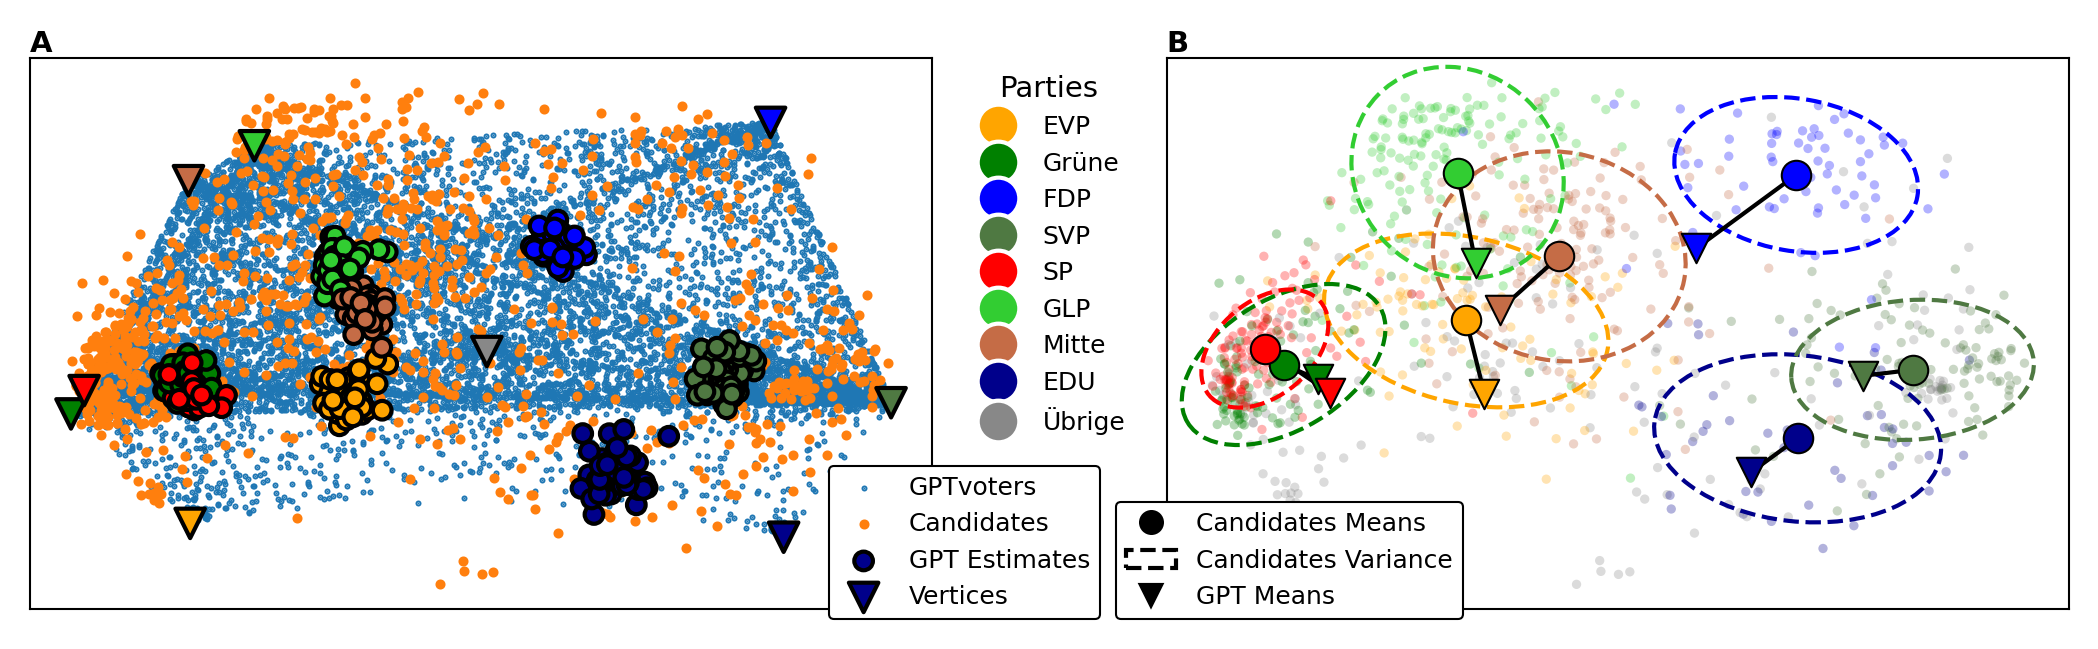

In [32]:

fig, (bx, ax) = plt.subplots(1, 2, figsize=(vis.textwidth, 0.4*vis.textwidth))
bx.set_aspect('equal')
ax.set_aspect('equal')

bx.scatter(Q.loc[:,'X'], Q.loc[:,'Y'], s=.2, lw=None, label='GPTvoters')
# bx.scatter(Q.loc[:,'X'], Q.loc[:,'Y'], s=.2, lw=None, label='GPTvoters')
bx.scatter(E.loc[:,'X'], E.loc[:,'Y'], s=2, lw=1, label='Candidates')
colors = gpt_data.index.get_level_values(0).map(vis.party_colors)
bx.scatter(P.loc[:,'X'], P.loc[:,'Y'], s=20, lw=1, c=colors, edgecolors='black',label='GPT Estimates')
colors = vertices.index.get_level_values(0).map(vis.party_colors)
bx.scatter(T.loc[:,'X'], T.loc[:,'Y'], s=50,marker='v', c=colors, label='Vertices', edgecolors='black', zorder=10)

ax.scatter(E.loc[:,'X'],E.loc[:,'Y'], c=candidates.color, s=5, edgecolor='none', alpha=0.3)
for name, data in E.groupby(level=0):
    if len(data) > 1 and name != "Übrige":
        G = GaussianDistribution().estimate(data.values)
        x_mean,y_mean = G.mean
        c = vis.party_colors.get(name, 'gray')
        ax.scatter(x_mean,y_mean, c=c, marker='o', s=50,  edgecolors='black', lw=.5, zorder=3)
        plotGaussian(G, size=0, STDS=[1.5], color=c, lw=1, ax=ax)
        x, y =M.loc[name]
        ax.plot([x_mean, x], [y_mean,y], c='black', lw=1)
        ax.scatter(x,y, c=c, s=50, edgecolors='black', marker='v', lw=.5 ,zorder=4, label=name)
        
# Creating custom legend handles
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Candidates Means',
           markerfacecolor='black', markersize=5, markeredgecolor='black', lw=0.5),
    Patch(facecolor='none', edgecolor='black', label='Candidates Variance', linestyle='--', lw=1),
    Line2D([0], [0], marker='v', color='w', label='GPT Means',
           markerfacecolor='black', markersize=5, markeredgecolor='black', lw=0.5)
]

# Party colors
legend_elements_1 = [Line2D([0], [0], marker='o', color='w', label=key, markersize=10, markerfacecolor=val) for key, val in vis.party_colors.items() if key in candidates.list.unique()]

leg_offset = 0.06
# Creating the legend with two columns
leg1 = bx.legend(handles=legend_elements_1, loc='upper left', bbox_to_anchor=(1.02, 1.01), title='Parties', ncol=1, frameon=False)
leg2 = ax.legend(handles=legend_elements, loc='lower left', bbox_to_anchor=(-.13+leg_offset,-.04), ncol=1)

# Create first legend
bx.add_artist(leg1)  # Add the first legend manually
# leg2 = bx.legend(loc='center', bbox_to_anchor=(.5, -.07), ncol=1, borderaxespad=0.)
leg3 = bx.legend(loc='lower right', bbox_to_anchor=(1.14+leg_offset,-.04), ncol=1)

for leg in (leg1, leg2, leg3):
    leg.get_frame().set_edgecolor('black')  # Border color
    leg.get_frame().set_linewidth(.5)        # Border thickness
    leg.get_frame().set_facecolor('white')  # Set background color to white (or any solid color)
    leg.get_frame().set_alpha(1)            # Background opacity set to 1 (opaque)

fig.text(-0,1, 'A', va='bottom', ha='left', weight='bold', transform=bx.transAxes)
fig.text(-0,1, 'B', va='bottom', ha='left', weight='bold', transform=ax.transAxes)
ax.tick_params(left = False, right = False , labelleft = False , labelbottom = False, bottom = False)
bx.tick_params(left = False, right = False , labelleft = False , labelbottom = False, bottom = False)

ax.set_xlim(bx.get_xlim())
ax.set_ylim(bx.get_ylim())

fig.tight_layout()
plt.subplots_adjust(wspace=.26)
vis.savefig(fig, 'GPT_Voters_PCA', save_figures)

# Print the size of the figure
print("Figure size in inches:", fig.get_size_inches()/vis.inches_pt)
print("Aspect ratio of the figure:", fig.get_figheight()/fig.get_figwidth())


## Simulation Experiments

In [2]:
def plot_selection(identifiers, **kwargs):
    params = {'metric': 'RMSE',
              'window': 10,
              'ncols': 2,
              'xmax':None,
              'title':False,
              'ax': None,
              'figwidth': vis.textwidth,
              'figratio': 0.5,
              'smooth': True,
              'legend':True,
              'lw':1}
    params.update(kwargs)
    
    if params['ax'] is None:
        fig, ax = plt.subplots(figsize=(params['figwidth'], params['figratio']*params['figwidth']))
    else:
        fig, ax = params['ax'].figure, params['ax']
        
    common_title_parts = []

    # Create a mapping of column names to list indices
    identifying = ['InitialData', 'Method', 'NumberQueries', 'Model', 'UpdateRate']
    col_to_index = {col: i for i, col in enumerate(identifying)}

    # Determine common and different parts for title and legend
    array_ids = pd.DataFrame(identifiers, columns=identifying+['Baseline']).drop('Baseline', axis=1)
    common_title_parts = array_ids.columns[array_ids.nunique() == 1].tolist()
    different_legend_parts = array_ids.columns[array_ids.nunique() > 1].tolist()

    title=''
    if params['title']:
    # Title for common elements
        title = params['metric']+': '+'_'.join(array_ids[col].iloc[0] for col in common_title_parts)

    stats = {}
    for identifier in identifiers:
        # Create a mask to filter rows based on the identifier
        mask = (results.loc[:, identifying] == identifier[:-1]).all(axis=1)
        df = results.loc[mask, 'DataFrame']
        if df.empty:
            logger.info(f'No results found for {identifier}.')
        else:
            logger.info(f'{identifier[:-1]} has {mask.sum()} hits.')
            data = results.loc[mask, 'DataFrame'].apply(lambda df: df.groupby('ModelVersion')[params['metric']].mean())
            if params['smooth']:
                data = data.rolling(window=params['window'], min_periods=1, center=True, axis=1).mean()
                moving_avg = data.mean()
            else:
                moving_avg = data.mean().rolling(window=params['window'], min_periods=1, center=True).mean()
            means = data.mean()
            stds = data.std()
            s = np.sqrt(mask.sum())
            singles = stds.isna()

            # Generate the legend label using different_legend_parts and mapping
            legend_label = ' '.join(identifier[col_to_index[col]] for col in different_legend_parts)
            if identifier[-1]:
                # Add average as dashed line
                ax.axhline(means.mean(), lw=0.5, ls='dashed', zorder=5, color='black' ,label=legend_label)
            else:
                # Add MEAN where there is no STD (noisy line)
                # line, = ax.plot(means.index, means.values, lw=.5, ls='dashed')
                # Add MEAN where there is STD (slightly noisy line)
                # line, = ax.plot(means.loc[~singles].index, means.loc[~singles].values, c=line.get_color(), lw=1)
                # Add AVERAGE where there is no STD (rolling mean)
                ax.plot(moving_avg.index, moving_avg.values, lw=params['lw'], label=legend_label)
                # Add Confidence where there is STD (suasage)
                # ax.fill_between(means.index, means-stds/s, means+stds/s, color=line.get_color(), alpha=0.4)
            stats[legend_label] = means, stds/s
    ax.set(title=title,
           xlabel='Users',
           ylabel=params['metric'])
    if params['xmax'] is None:
        ax.set_xlim(left=0)
    else:
        ax.set(xlim=(0,params['xmax']))
    if params['legend']:
        leg = ax.legend(ncol=params['ncols'], loc='best', facecolor='w')
        leg.get_frame().set_alpha(1)  
    fig.tight_layout()
    return fig, stats


def first_all_positive_index(series):
    # Drop NaN values for the check, but retain original indices
    filtered_series = series.dropna()
    for i in filtered_series.index:
        # Check if all elements from the current index to the end are positive
        if all(x >= 0 for x in filtered_series.loc[i:]):
            return i
    return None  # Return None if no such index exists


def first_positive_index(series):
    # Drop NaN values for the check, but retain original indices
    filtered_series = series.dropna()
    for i in filtered_series.index:
        # Check if all elements from the current index to the end are positive
        if filtered_series.loc[i] >=0:
            return i
    return None  # Return None if no such index exists


### Comparing Datasets

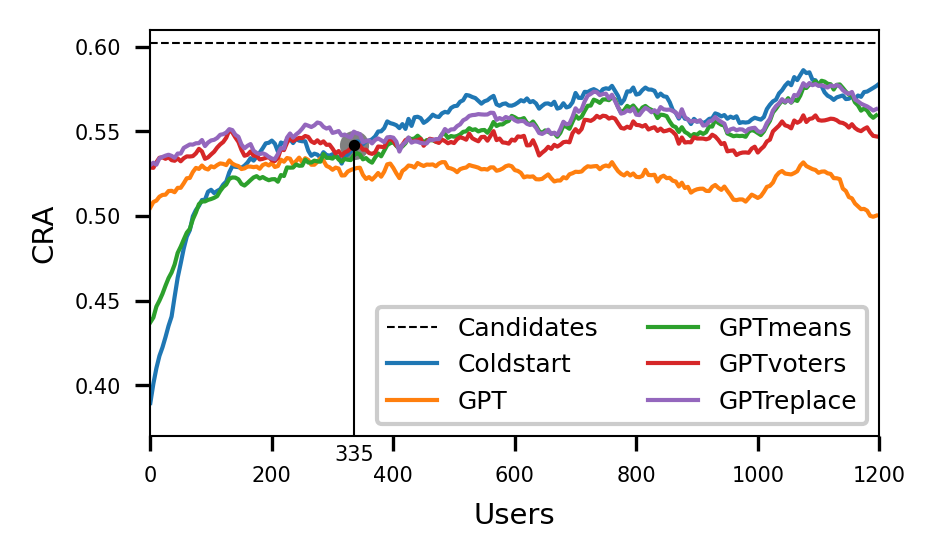

In [ ]:
logger.setLevel(1000)
number_queries = 40
identifiersCRA = [
# ['Voters', 'Uncertainty', f'{number_queries}Q', 'XPLORE', '5U', True],
['Candidates', 'Uncertainty', f'{number_queries}Q', 'XPLORE', '5U', True],
['Coldstart', 'Uncertainty', f'{number_queries}Q', 'XPLORE', '5U', False],
['GPT', 'Uncertainty', f'{number_queries}Q', 'XPLORE', '5U', False],
['GPTmeans', 'Uncertainty', f'{number_queries}Q', 'XPLORE', '5U', False],
['GPTvoters', 'Uncertainty', f'{number_queries}Q', 'XPLORE', '5U', False],
['GPTreplace', 'Uncertainty', f'{number_queries}Q', 'XPLORE', '5U', False],
]

results = prep.load_results()
fig, stats40Q = plot_selection(identifiersCRA, metric='CRA', figratio=0.6, window=15, xmax=1200, figwidth=vis.columnwidth)

GPTvoters_stats = pd.DataFrame.from_dict(stats40Q, orient='index').loc['GPTvoters']
Coldstart_stats = pd.DataFrame.from_dict(stats40Q, orient='index').loc['Coldstart']
difference = - GPTvoters_stats.iloc[0] - GPTvoters_stats.iloc[1] + Coldstart_stats.iloc[0] + Coldstart_stats.iloc[1] 
idx = first_all_positive_index(difference)
val = GPTvoters_stats.iloc[0].loc[idx]
ax = fig.axes[0]
ax.plot([idx, idx], [0.37,val], c='black', lw=0.5)
ax.scatter(idx, val, zorder=0, c='grey')
ax.scatter(idx, val, zorder=3, s=3, c='black')
ax.text(idx, 0.365, idx, rotation='horizontal', va='top', ha='center', fontsize=5) 
ax.set_ylim((0.37, 0.61))

# vis.savefig(fig, title=f'Datasets_{number_queries}Q_CRA', destinations=save_figures)

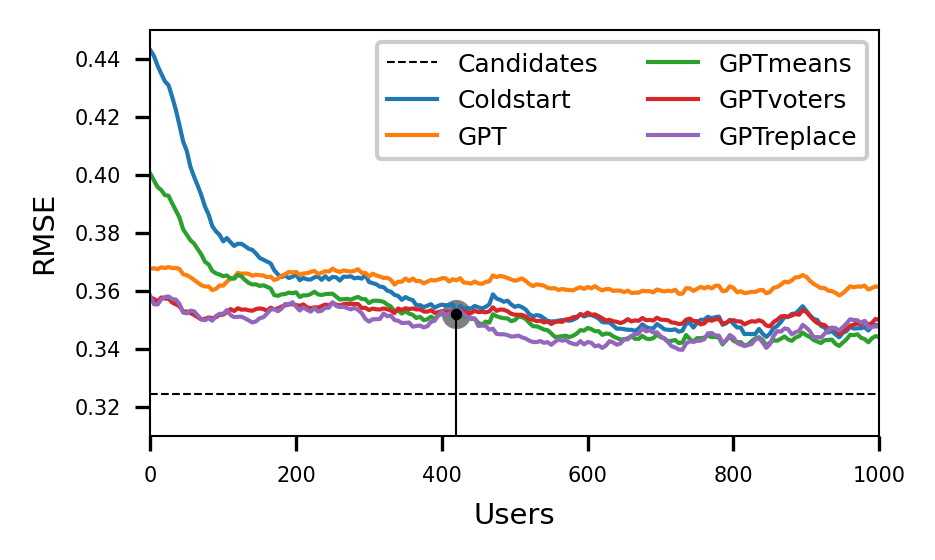

In [ ]:
number_queries = 10
metric = 'RMSE'
identifiersRMSE = [
# ['Voters', 'Uncertainty', f'{number_queries}Q', 'XPLORE', '5U', False],
['Candidates', 'Uncertainty', f'{number_queries}Q', 'XPLORE', '5U', True],
['Coldstart', 'Uncertainty', f'{number_queries}Q', 'XPLORE', '5U', False],
['GPT', 'Uncertainty', f'{number_queries}Q', 'XPLORE', '5U', False],
['GPTmeans', 'Uncertainty', f'{number_queries}Q', 'XPLORE', '5U', False],
['GPTvoters', 'Uncertainty', f'{number_queries}Q', 'XPLORE', '5U', False],
['GPTreplace', 'Uncertainty', f'{number_queries}Q', 'XPLORE', '5U', False],
]

results = prep.load_results()
fig, stats10Q = plot_selection(identifiersRMSE, metric=metric, figratio=0.6, xmax=1000, window=10, figwidth=vis.columnwidth)

GPTvoters_stats = pd.DataFrame.from_dict(stats10Q, orient='index').loc['GPTvoters']
Coldstart_stats = pd.DataFrame.from_dict(stats10Q, orient='index').loc['Coldstart']
difference = GPTvoters_stats.iloc[0] + GPTvoters_stats.iloc[1] - Coldstart_stats.iloc[0] + Coldstart_stats.iloc[1] 
difference = GPTvoters_stats.iloc[0] - Coldstart_stats.iloc[0] 
idx = first_positive_index(difference)
val = Coldstart_stats.iloc[0].loc[idx]
ax = fig.axes[0]
ax.plot([idx, idx], [0.31,val], c='black', lw=0.5)
ax.scatter(idx, val, zorder=0, c='grey')
ax.scatter(idx, val, zorder=3, s=3, c='black')
# fig.axes[0].axvline(idx, c='black', lw=0.5)
ax.set_ylim((0.31, 0.45))


# vis.savefig(fig, title=f'Datasets_{number_queries}Q_{metric}', destinations=save_figures)

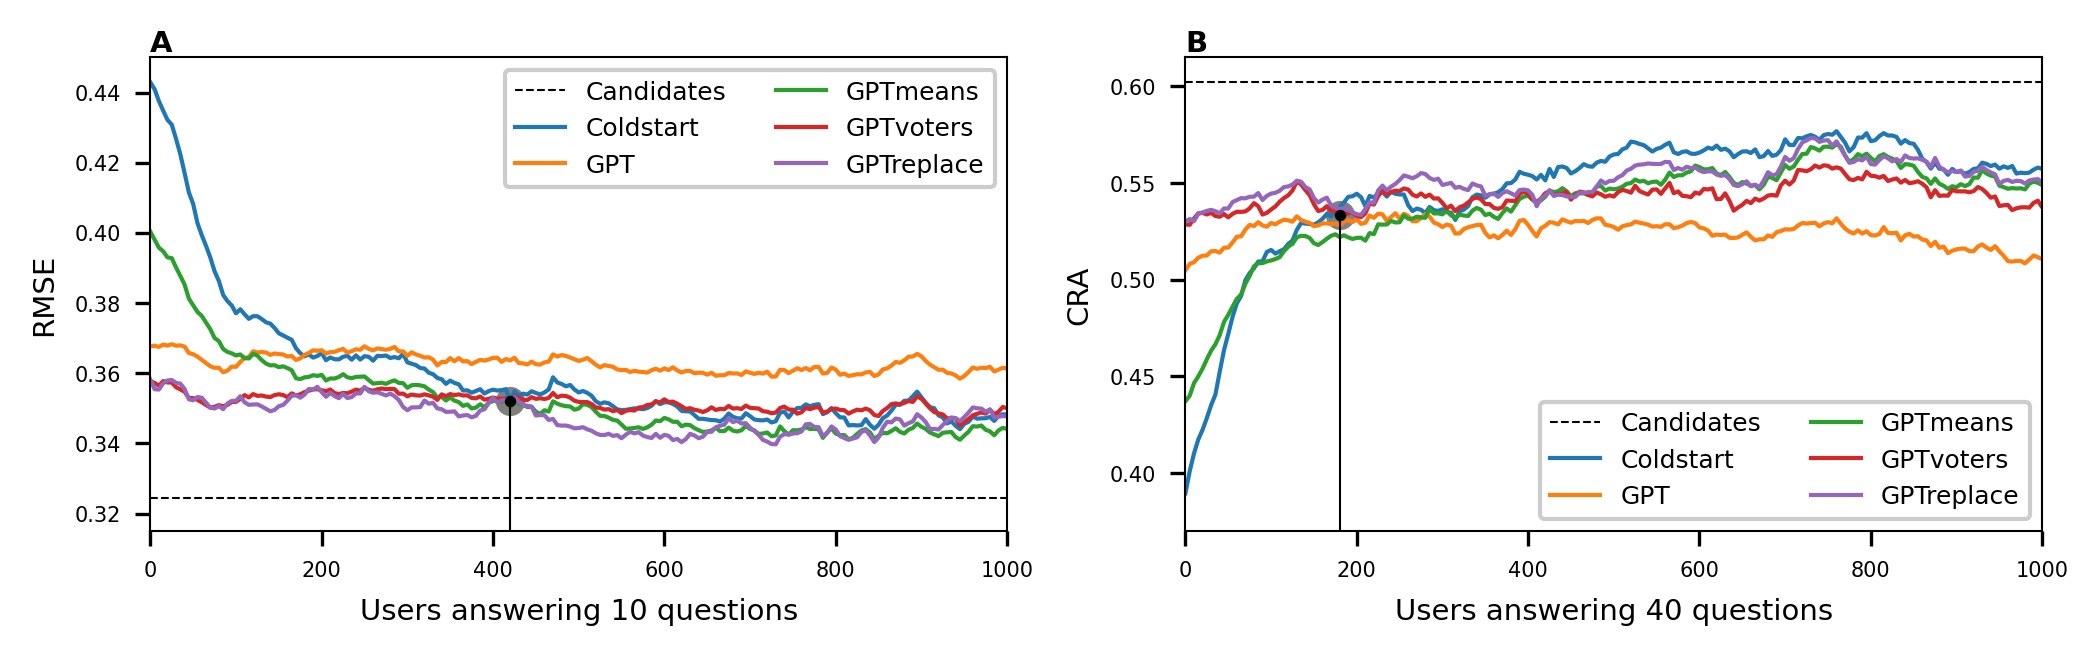

In [5]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(vis.textwidth, 0.3*vis.textwidth))

results = prep.load_results()
fig, stats40Q = plot_selection(identifiersCRA, metric='CRA', window=15, xmax=1000, ax=ax2)

GPTvoters_stats = pd.DataFrame.from_dict(stats40Q, orient='index').loc['GPTvoters']
Coldstart_stats = pd.DataFrame.from_dict(stats40Q, orient='index').loc['Coldstart']
difference = - GPTvoters_stats.iloc[0] - GPTvoters_stats.iloc[1] + Coldstart_stats.iloc[0] + Coldstart_stats.iloc[1] 
idx = first_positive_index(difference)
val = GPTvoters_stats.iloc[0].loc[idx]
ax2.plot([idx, idx], [0.37,val], c='black', lw=0.5)
ax2.scatter(idx, val, zorder=0, c='grey')
ax2.scatter(idx, val, zorder=3, s=3, c='black')
# ax2.text(idx, 0.365, idx, rotation='horizontal', va='top', ha='center', fontsize=5) 
ax2.set(ylim=(0.37, 0.615),
        xlabel=f'Users answering 40 questions')


fig, stats10Q = plot_selection(identifiersRMSE, metric='RMSE', xmax=1000, window=10, ax=ax1)

GPTvoters_stats = pd.DataFrame.from_dict(stats10Q, orient='index').loc['GPTvoters']
Coldstart_stats = pd.DataFrame.from_dict(stats10Q, orient='index').loc['Coldstart']
difference = GPTvoters_stats.iloc[0] + GPTvoters_stats.iloc[1] - Coldstart_stats.iloc[0] + Coldstart_stats.iloc[1] 
difference = GPTvoters_stats.iloc[0] - Coldstart_stats.iloc[0] 
idx = first_positive_index(difference)
val = Coldstart_stats.iloc[0].loc[idx]
ax1.plot([idx, idx], [0.315,val], c='black', lw=0.5)
ax1.scatter(idx, val, zorder=0, c='grey')
ax1.scatter(idx, val, zorder=3, s=3, c='black')
# fig.axes[0].axvline(idx, c='black', lw=0.5)
ax1.set(ylim=(0.315, 0.45),
        xlabel=f'Users answering 10 questions')
fig.text(-0,1, 'A', va='bottom', ha='left', weight='bold', transform=ax1.transAxes)
fig.text(-0,1, 'B', va='bottom', ha='left', weight='bold', transform=ax2.transAxes)

fig.tight_layout()
vis.savefig(fig, title=f'Simulation_Results', destinations=save_figures)

### Break even points

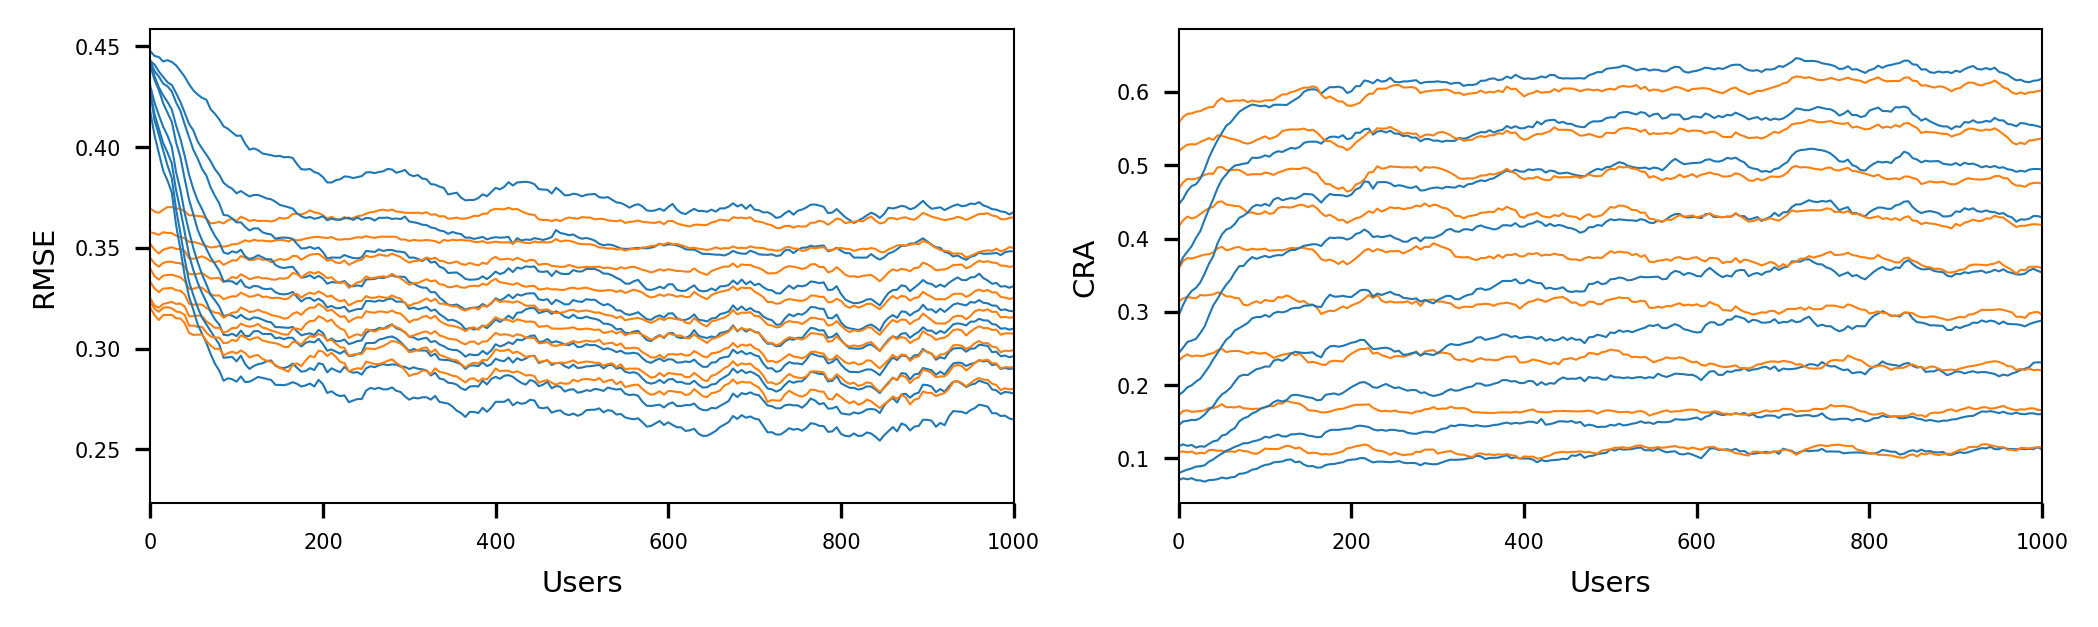

In [19]:
figBEP, (ax1, ax2) = plt.subplots(1,2, figsize=(vis.textwidth, 0.3*vis.textwidth))

number_queries_list = list(range(5,50,5))
identifiers = []
for number_queries in number_queries_list:
    identifiers += [
['Coldstart', 'Uncertainty', f'{number_queries}Q', 'XPLORE', '5U', False],
['GPTvoters', 'Uncertainty', f'{number_queries}Q', 'XPLORE', '5U', False],
]

results = prep.load_results()
fig, statsRMSE = plot_selection(identifiers, metric='RMSE', legend=False, lw=0.5, figratio=0.6, xmax=1000, ax=ax1, window=10, figwidth=0.5*vis.textwidth)

lines = fig.axes[0].get_lines()

# Change the color of all lines, alternating between blue and orange
for i, line in enumerate(lines):
    line.set_color(['C0','C1'][i % 2])  # Use modulo to alternate colors

fig, statsCRA = plot_selection(identifiers, metric='CRA', legend=False, lw=.5, figratio=0.6, xmax=1000, ax=ax2,  window=10, figwidth=.5*vis.textwidth)
lines = fig.axes[1].get_lines()

# Change the color of all lines, alternating between blue and orange
for i, line in enumerate(lines):
    line.set_color(['C0','C1'][i % 2])  # Use modulo to alternate colors



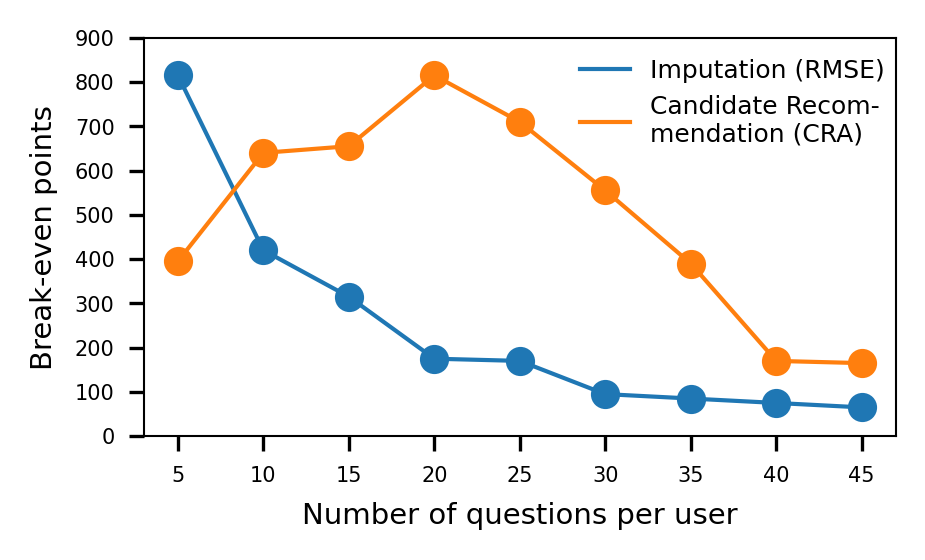

In [ ]:
RMSE = []
RMSEval = []
for number_queries in number_queries_list:
    A = f'GPTvoters {number_queries}Q'
    B = f'Coldstart {number_queries}Q'
    data =pd.DataFrame.from_dict(statsRMSE, orient='index')
    if A in data.index and B in data.index:
        GPTvoters_stats = data.loc[A]
        Coldstart_stats = data.loc[B]
        difference = GPTvoters_stats.iloc[0] + GPTvoters_stats.iloc[1] - Coldstart_stats.iloc[0] + Coldstart_stats.iloc[1] 
        difference = GPTvoters_stats.iloc[0] - Coldstart_stats.iloc[0] 
        idx = first_positive_index(difference)
        RMSE.append(idx)
        RMSEval.append(GPTvoters_stats.iloc[0].loc[idx])
    else:
        RMSE.append(np.nan)
        RMSEval.append(np.nan)

CRA = []
CRAval = []
for number_queries in number_queries_list:
    A = f'GPTvoters {number_queries}Q'
    B = f'Coldstart {number_queries}Q'
    data =pd.DataFrame.from_dict(statsCRA, orient='index')
    if A in data.index and B in data.index:
        GPTvoters_stats = data.loc[A]
        Coldstart_stats = data.loc[B]
        difference = GPTvoters_stats.iloc[0] + GPTvoters_stats.iloc[1] - Coldstart_stats.iloc[0] + Coldstart_stats.iloc[1] 
        difference = GPTvoters_stats.iloc[0] - Coldstart_stats.iloc[0] 
        idx = first_positive_index(-difference)
        CRA.append(idx)
        CRAval.append(GPTvoters_stats.iloc[0].loc[idx])
    else:
        CRA.append(np.nan)
        CRAval.append(np.nan)

fig, ax  = plt.subplots(figsize=(vis.columnwidth, 0.6*vis.columnwidth))
ax.plot(number_queries_list, RMSE, label='Imputation (RMSE)')
ax.plot(number_queries_list, CRA, label='Candidate Recom-\nmendation (CRA)')
ax.scatter(number_queries_list, RMSE, zorder=2)
ax.scatter(number_queries_list, CRA, zorder=2)

ax.set(ylim=(0,900),
       xlim=(3,47),
       xlabel='Number of questions per user',
       ylabel='Break-even points')
leg = ax.legend( bbox_to_anchor=(0.55, 0.67), frameon=False, facecolor='w')#, title='Downstream task')
leg.get_frame().set_alpha(1) 
fig.tight_layout()
# vis.savefig(fig, 'Simulation_Intersection_Points', save_figures)

In [21]:
thresholds = pd.DataFrame([RMSE, RMSEval, CRA, CRAval], columns=number_queries_list, index=['RMSE', 'RMSEval', 'CRA', 'CRAval']).T
thresholds

,RMSE,RMSEval,CRA,CRAval
5,815.0,0.362957,395.0,0.099611
10,420.0,0.352134,640.0,0.159861
15,315.0,0.343981,655.0,0.223278
20,175.0,0.335312,815.0,0.298778
25,170.0,0.327160,710.0,0.366944
30,95.0,0.317843,555.0,0.423778
35,85.0,0.307825,390.0,0.489222
40,75.0,0.305456,170.0,0.533000
45,65.0,0.303939,165.0,0.596333


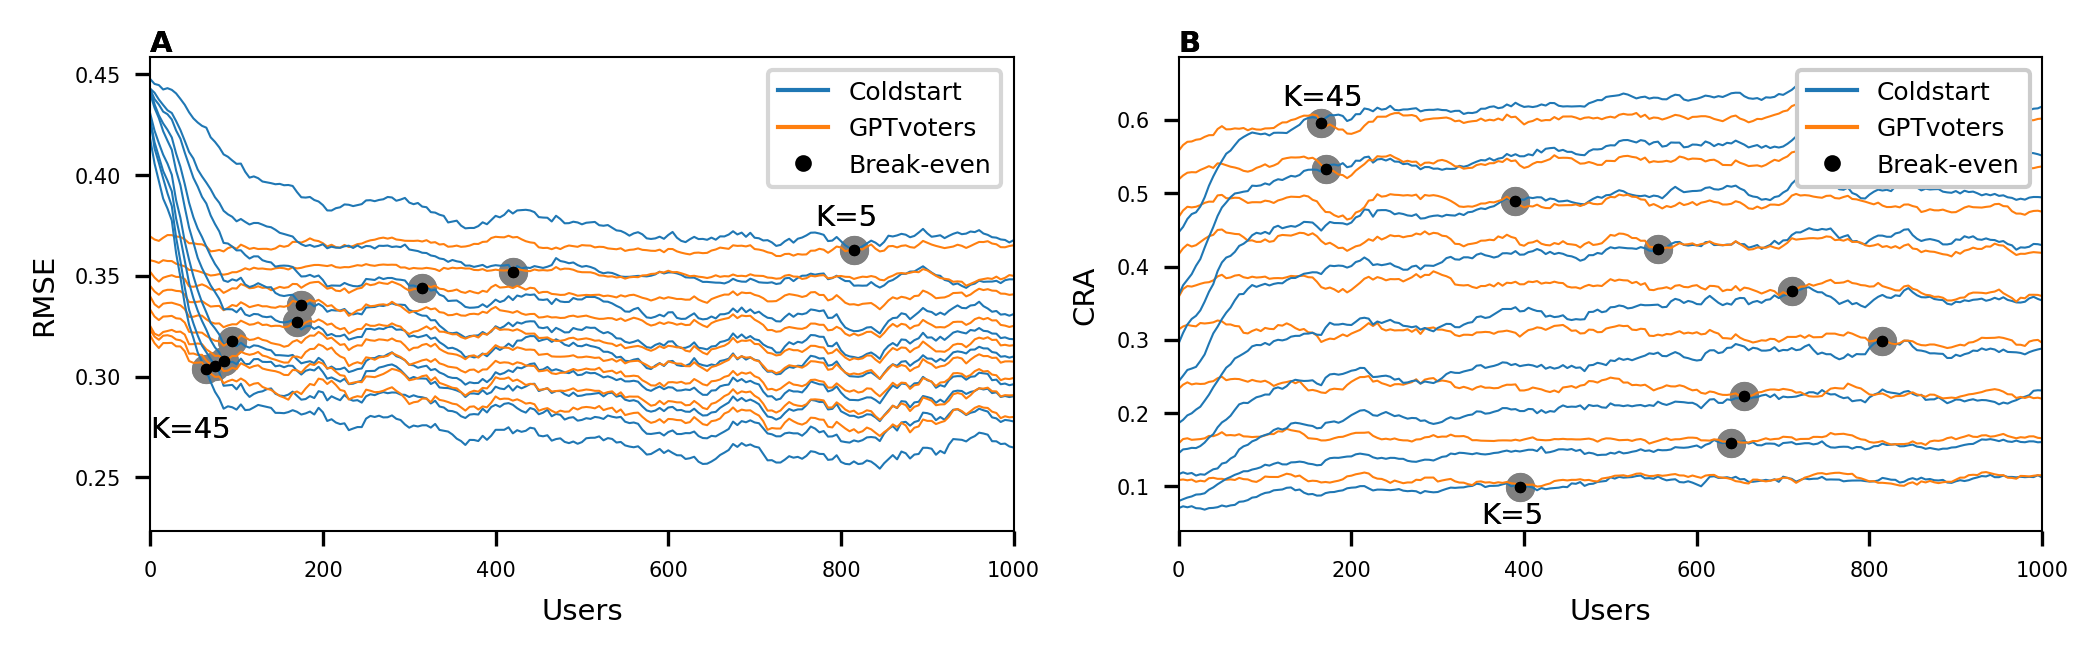

In [23]:
ax = figBEP.axes[0]
lines = ax.get_lines()
ax.scatter(thresholds['RMSE'], thresholds['RMSEval'], zorder=0, c='grey')
ax.scatter(thresholds['RMSE'], thresholds['RMSEval'], zorder=3, s=3, c='black')
blue_line = mlines.Line2D([], [], color='C0', label='Coldstart')
orange_line = mlines.Line2D([], [], color='C1', label='GPTvoters')
black_dot = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                          markersize=3, label='Break-even')  # Adjusted for visual size matching

# Add a legend with custom handles
ax.legend(handles=[blue_line, orange_line, black_dot])
ax.text(770, 0.375, 'K=5')
ax.text(0, 0.27, 'K=45')
figBEP.text(-0,1, 'A', va='bottom', ha='left', weight='bold', transform=ax.transAxes)

ax = figBEP.axes[1]
lines = ax.get_lines()
ax.scatter(thresholds['CRA'], thresholds['CRAval'], zorder=0, c='grey')
ax.scatter(thresholds['CRA'], thresholds['CRAval'], zorder=3, s=3, c='black')
blue_line = mlines.Line2D([], [], color='C0', label='Coldstart')
orange_line = mlines.Line2D([], [], color='C1', label='GPTvoters')
black_dot = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                          markersize=3, label='Break-even')  # Adjusted for visual size matching

figBEP.text(-0,1, 'B', va='bottom', ha='left', weight='bold', transform=ax.transAxes)
# Add a legend with custom handles
leg = ax.legend(handles=[blue_line, orange_line, black_dot], loc='upper right', facecolor='w')
leg.get_frame().set_alpha(1)  
ax.text(120, 0.62, 'K=45')
ax.text(350, 0.05, 'K=5')

vis.savefig(figBEP, 'Simulation_Intersection_Points', save_figures)
# figBEP.savefig('../reports/PLOS Paper/figures/Simulation_Intersection_Points.pdf', bbox_inches='tight')

figBEP

## Queries

In [2]:
results = prep.load_results()

results.iloc[0,7].Queries.iloc[0]#apply(lambda row: )

"['32216', '32248', '32250', '32253', '32254', '32255', '32265', '32270', '32271', '32286']"

In [28]:
results.iloc[0,7].sample(n=1,random_state=0)

,User,RMSE,CRA,ModelVersion,TimeStamp,Queries
198,191439,0.520518,0.0,195,2024-09-26 10:48:00.494229,"['32230', '32239', '32244', '32245', '32248', ..."


### Renaming

In [9]:
import os

def rename_files(directory, old_str, new_str):
    # List all files in the given directory
    for filename in os.listdir(directory):
        if filename.endswith(".csv") and old_str in filename:  # Check if the filename ends with .csv and contains the old string
            # Construct new filename
            new_filename = filename.replace(old_str, new_str)
            # Construct full file paths
            old_file_path = os.path.join(directory, filename)
            new_file_path = os.path.join(directory, new_filename)
            # Rename the file
            os.rename(old_file_path, new_file_path)
            print(f'Renamed "{filename}" to "{new_filename}"')

# Usage
directory = '../results/aqvaa'  # Set the directory path
rename_files(directory, 'update', 'replace')

Renamed "GPTupdate_Uncertainty_10Q_XPLORE_5U_1200V_S8.csv" to "GPTreplace_Uncertainty_10Q_XPLORE_5U_1200V_S8.csv"
Renamed "GPTupdate_Uncertainty_10Q_XPLORE_5U_1200V_S9.csv" to "GPTreplace_Uncertainty_10Q_XPLORE_5U_1200V_S9.csv"
Renamed "GPTupdate_Uncertainty_10Q_XPLORE_5U_1200V_S1.csv" to "GPTreplace_Uncertainty_10Q_XPLORE_5U_1200V_S1.csv"
Renamed "GPTupdate_Uncertainty_10Q_XPLORE_5U_1200V_S0.csv" to "GPTreplace_Uncertainty_10Q_XPLORE_5U_1200V_S0.csv"
Renamed "GPTupdate_Uncertainty_10Q_XPLORE_5U_1200V_S2.csv" to "GPTreplace_Uncertainty_10Q_XPLORE_5U_1200V_S2.csv"
Renamed "GPTupdate_Uncertainty_10Q_XPLORE_5U_1200V_S3.csv" to "GPTreplace_Uncertainty_10Q_XPLORE_5U_1200V_S3.csv"
Renamed "GPTupdate_Uncertainty_10Q_XPLORE_5U_1200V_S7.csv" to "GPTreplace_Uncertainty_10Q_XPLORE_5U_1200V_S7.csv"
Renamed "GPTupdate_Uncertainty_10Q_XPLORE_5U_1200V_S6.csv" to "GPTreplace_Uncertainty_10Q_XPLORE_5U_1200V_S6.csv"
Renamed "GPTupdate_Uncertainty_10Q_XPLORE_5U_1200V_S4.csv" to "GPTreplace_Uncertainty_10

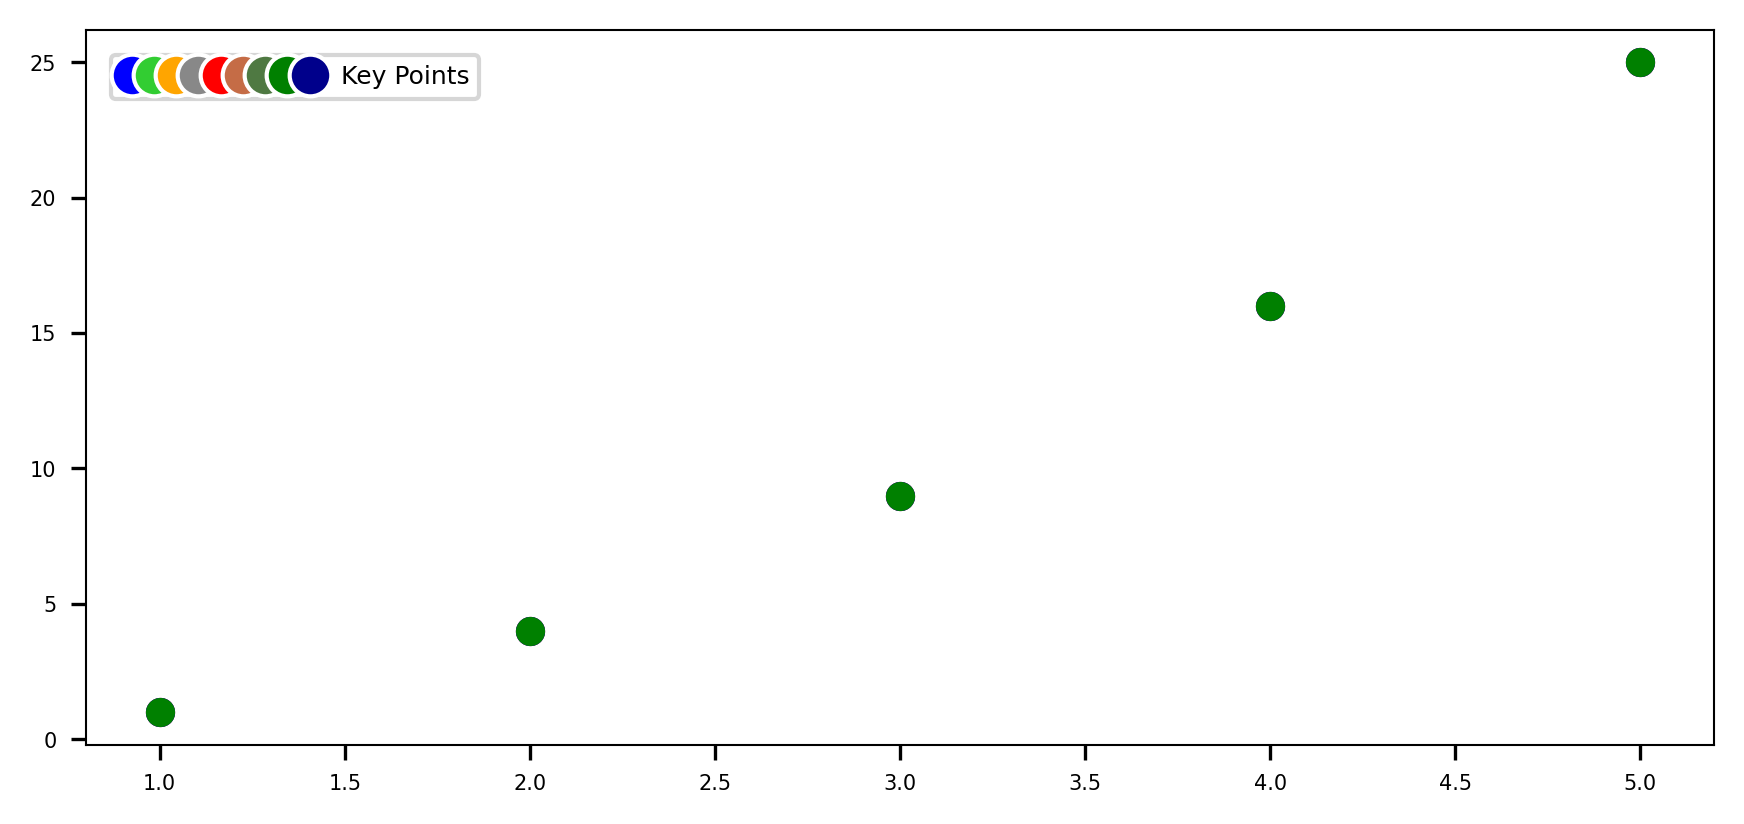

In [71]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

# Define your colors in a dictionary
color_dict = {'First': 'red', 'Second': 'blue', 'Third': 'green'}

# Example data
x = [1, 2, 3, 4, 5]
y = [i**2 for i in x]  # Just an example relationship

# Plotting the data (not actually displayed, but we prepare the colors)
for key, color in color_dict.items():
    plt.plot(x, y, 'o', color=color, label=key)

# Create legend elements from the color dictionary
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in candidates.color.unique()]

# Creating the legend
plt.legend([tuple(legend_elements)], ['Key Points'], handler_map={tuple: HandlerTuple(ndivide=None, pad=0)},
                handlelength=8,  # Increase handle length to accommodate more space for markers
                borderaxespad=1,  # Adjust spacing between the legend content and the border
                labelspacing=2  # Increase the vertical spacing between the legend entries
    )

plt.show()